In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

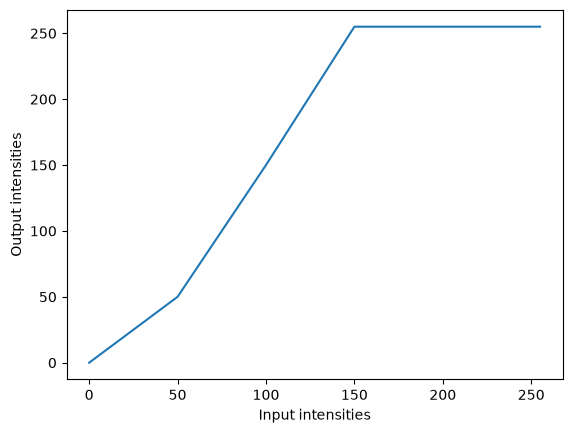

In [3]:
input_intensity=[0,50,100,150,255]
output_intensity=[0,50,150,255,255]

plt.plot(input_intensity,output_intensity)
plt.xlabel("Input intensities")
plt.ylabel("Output intensities")
plt.show()



In [ ]:
#Defining the function
def intensity_transform(pix,b1,b2,b3,b4,b5):
    if b1<=pix<=b2:
        pix_out=pix
    elif b2<pix<=b3:
        pix_out=50+((pix-b2)*(150-50)/(100-50))
    elif b3<pix<=b4:
            pix_out=150+((pix-b3)*(255-150)/(150-100))
    elif b4<pix<=b5:
            pix_out=255
    return pix_out        

    


In [5]:
#vectorizing the function
vec_trans=np.vectorize(intensity_transform)

In [9]:
#reading the image as a grayscle image
img=cv.imread("image_1.png",cv.IMREAD_GRAYSCALE)
print(len(img[1]))
print(img.shape)

582
(658, 582)


In [26]:
#applied the vectorized transformation on image
transformed_image=vec_trans(img,0,50,100,150,255)
print(transformed_image.shape)

(658, 582)


(np.float64(-0.5), np.float64(581.5), np.float64(657.5), np.float64(-0.5))

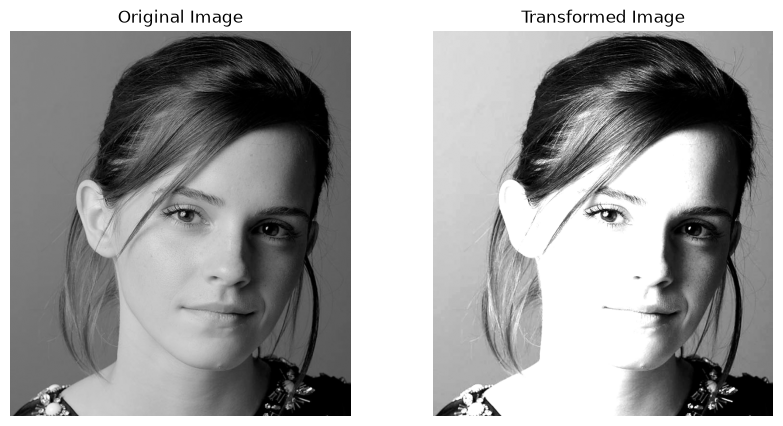

In [58]:
#plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed_image, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

Question 2

In [104]:
img_2=cv.imread('image_2.png',cv.IMREAD_GRAYSCALE)

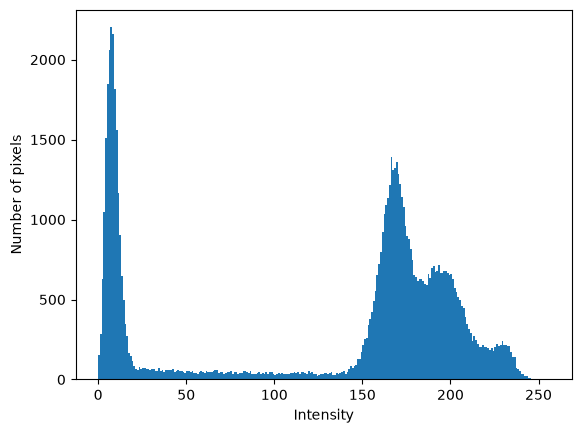

In [105]:
#first look at the intensity distrrbution
plt.hist(img_2.ravel(), bins=256, range=[0,256])
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

In [122]:
def filter_matter(pix, t1, t2, t3):

    if pix < t1:
        pix_out = 0

    elif pix < t2:
        pix_out = 100

    elif pix < t3:
        pix_out = 200

    else:
        pix_out = 255

    return pix_out

In [115]:
# #looking for a sweetspot value for threshold
# test_array=np.arange(170,180)
# vec_fillter=np.vectorize(filter_matter)
# for value in test_array:
#     filtered_image = vec_fillter(img_2,value)
#     plt.figure(figsize=(5,5))
#     plt.imshow(filtered_image,cmap='gray')
#     plt.title(f"{value}")

In [128]:
vec_fillter=np.vectorize(filter_matter)
filtered_image = vec_fillter(img_2, 150, 180, 210)

(np.float64(-0.5), np.float64(251.5), np.float64(300.5), np.float64(-0.5))

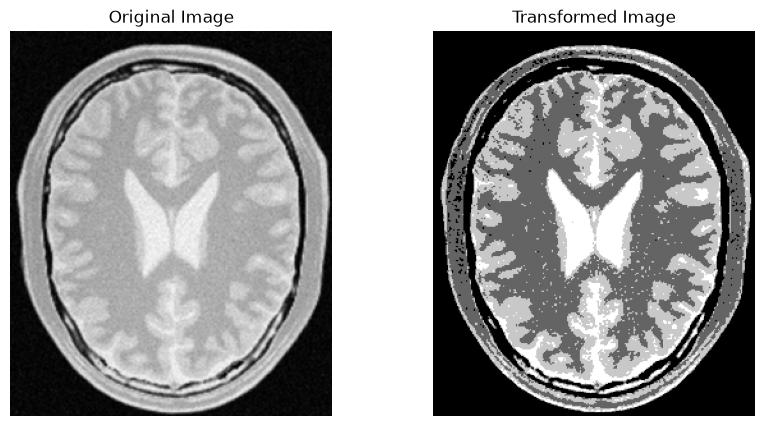

In [129]:
#plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_image, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

Question 3


In [133]:
#Read the mage
img_3=cv.imread("image_3.png")

#convert to LAB format
img_LAB=cv.cvtColor(img_3, cv.COLOR_BGR2LAB)
L,a,b= cv.split(img_LAB)

#normalize
L_norm= L/255.0

#Gamma correction
gamma=0.5
L_corrected=np.power(L_norm,gamma)

#convert back to 0-255
L_corrected=(L_corrected*255).astype(np.uint8)
Lab_merged=cv.merge([L_corrected,a,b,])

#BGR
corrected_img=cv.cvtColor(Lab_merged,cv.COLOR_LAB2BGR)


In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(img_3.ravel(), bins=256, range=[0, 256])
plt.title("Original L* Histogram")
plt.xlabel("L* intensity")
plt.ylabel("Number of pixels")

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=[0, 256])
plt.title("Corrected L* Histogram")
plt.xlabel("L* intensity")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()